In [2]:
# import libraries

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for model building and training
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# for evaluation
from sklearn.metrics import classification_report, confusion_matrix

# object and file loading
import pickle

ModelCheckpoint: Automatically saves the best model during training based on a monitored metric.

ReduceLROnPlateau: Automatically reduces the learning rate when the monitored metric stops improving for a specified number of epochs (patience).

In [3]:
# load the tokenized and padded data

X_train = np.load("../data/tokenized/X_train.npy")
X_test = np.load("../data/tokenized/X_test.npy")

y_train = np.load("../data/tokenized/y_train.npy")
y_test = np.load("../data/tokenized/y_test.npy")

In [4]:
# Verification of the loaded data

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(100000, 150)
(20000, 150)
(100000,)
(20000,)


In [5]:
# model paramters

with open("../models/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
    
VOCAB_SIZE = len(tokenizer.word_index) + 1
MAX_LEN = X_train.shape[1]
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
NUM_CLASSES = 5

In [9]:
# Build the model

model = Sequential([
    Input(shape = (MAX_LEN,)),
    
    Embedding(
        input_dim= VOCAB_SIZE,
        output_dim= EMBEDDING_DIM
    ),
    
    LSTM(LSTM_UNITS),      # internally uses tanh activation function
    
    Dropout(DROPOUT_RATE),
    
    Dense(64, activation= "relu"),
    
    Dropout(DROPOUT_RATE),
    
    Dense(NUM_CLASSES, activation= "softmax")
])

In [10]:
# Compile the model

model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │    13,292,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,346,437 (50.91 MB)

 Trainable params: 13,346,437 (50.91 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# defining callbacks

early_stopping = EarlyStopping(
    monitor= "val_loss",
    patience= 3,
    restore_best_weights= True
)

model_checkpoint = ModelCheckpoint(
    filepath= "../models/lstm_model_v1.keras",
    monitor= "val_loss",
    save_best_only= True,
    verbose= 1
)

reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.5,
    patience= 2,
    min_lr = 1e-6,
    verbose = 1
)


callbacks = [early_stopping, model_checkpoint, reduce_lr]


In [13]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    epochs = 10,
    batch_size = 64,
    callbacks = callbacks
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.2493 - loss: 1.5769
Epoch 1: val_loss improved from None to 1.53653, saving model to ../models/lstm_model_v1.keras

Epoch 1: finished saving model to ../models/lstm_model_v1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 315s 250ms/step - accuracy: 0.2493 - loss: 1.5769 - val_accuracy: 0.3149 - val_loss: 1.5365 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4617 - loss: 1.2100
Epoch 2: val_loss improved from 1.53653 to 1.07089, saving model to ../models/lstm_model_v1.keras

Epoch 2: finished saving model to ../models/lstm_model_v1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 111ms/step - accuracy: 0.4617 - loss: 1.2100 - val_accuracy: 0.5344 - val_loss: 1.0709 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5458 - loss: 1.0469
Epoch 3: val_loss improved from 1.07089 to 1.02245, saving model to ../models/lstm_model_v1.keras

Epoch 3: finish

In [14]:
# save the history

with open("../models/lstm_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

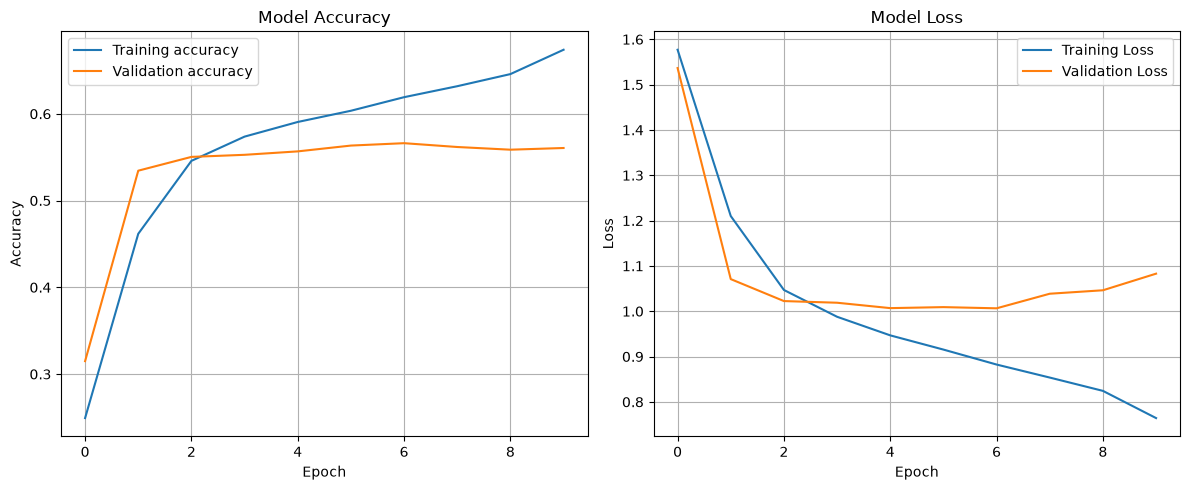

In [15]:
# Evaluation of model

plt.figure(figsize = (12, 5))

#accuracy 
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "Training accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Prediction

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis = 1)

625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step


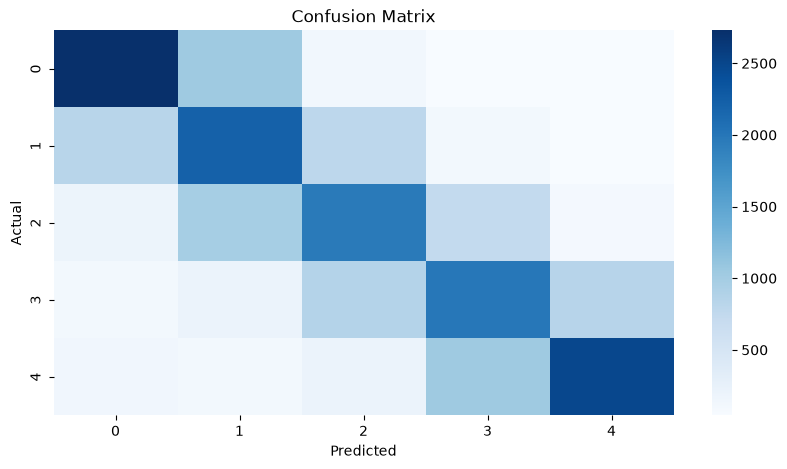

In [19]:
# Confusion matrix 

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize= (10, 5))
sns.heatmap(
    cm,
    fmt = "d",
    cmap = "Blues",
    xticklabels= [0, 1, 2, 3, 4],
    yticklabels= [0, 1, 2, 3, 4]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
# Classification report

cr = classification_report(
    y_test,
    y_pred
)

print(cr)

              precision    recall  f1-score   support

           0       0.68      0.68      0.68      4000
           1       0.49      0.55      0.52      4000
           2       0.50      0.49      0.49      4000
           3       0.51      0.50      0.50      4000
           4       0.71      0.62      0.66      4000

    accuracy                           0.57     20000
   macro avg       0.57      0.57      0.57     20000
weighted avg       0.57      0.57      0.57     20000

